In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from scipy.stats import lognorm
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import boxcox
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kstest
from scipy.stats import ks_2samp
from scipy.stats import ttest_ind
from scipy.stats import f
from scipy.stats import chi2
from scipy.stats import chi2_contingency
from scipy.stats import anderson

In [3]:
df=pd.read_csv("C:\\Users\\HP\\Downloads\\iris.data.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
#check dimention
df.ndim

2

In [4]:
#shape of the data set
df.shape

(150, 5)

In [5]:
#check columns
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [6]:
#data type tupes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
#duplicates
df.duplicated().sum()

np.int64(1)

# univariate analysis

C:\Users\HP\AppData\Local\Temp\ipykernel_12888\537145680.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['sepal_length'])


<Axes: xlabel='sepal_length', ylabel='Density'>

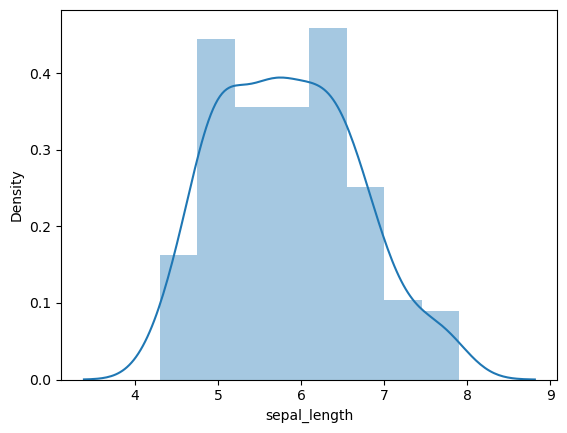

In [9]:
sns.distplot(df['sepal_length'])

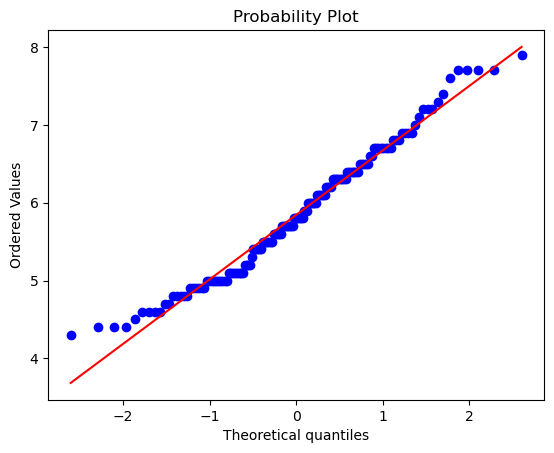

In [10]:
stats.probplot(df['sepal_length'],dist='norm',plot=plt)
plt.show()
#it is not compleatly gaussian distribution but some what gaussian distibution

In [11]:
#ks test
TS,P_value=kstest(df['sepal_length'],'norm')
P_value
#P_value of sepal_length lessthan 5% significant level so H0 is rejected

np.float64(0.0)

In [12]:
from scipy.stats import anderson
result=anderson(df['sepal_length'])
result
#Test_statastics of sepal_length is greaterthan 5% significant level so H0 is rejected sepal_lenght not a Gaussian

AndersonResult(statistic=np.float64(0.8891994860134105), critical_values=array([0.562, 0.64 , 0.767, 0.895, 1.065]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(5.843333333333334), scale=np.float64(0.8280661279778629))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [13]:
#Based on those observeations sepal_length is not following the Gaussain distribution

In [14]:
#estiamte a CLT to get a population mean of sl
def CLT(data,sample_size,no_sample):
    sample_means=[]
    for i in range(no_sample):
        get_sample=np.random.choice(data,sample_size)
        sample_means.append(np.mean(get_sample))
    return np.mean(sample_means)

In [15]:
data=df['sepal_length']
sample_size=30
no_sample=1000
CLT(data,sample_size,no_sample)
#Based on the sample data we are estimating the population mean

np.float64(5.838766666666666)

In [16]:
def Bootstrap(data,sample_size,no_sample):
    boot_data=[]
    for i in range(no_sample):
        get_sample=np.random.choice(data,sample_size)
        boot_data.append(np.median(get_sample))
    return boot_data
data=df['sepal_length']
sample_size=30
no_sample=1000
aaa=Bootstrap(data,sample_size,no_sample)

In [17]:
lower=np.percentile(aaa,2.5)
upper=np.percentile(aaa,97.5)

In [18]:
lower

np.float64(5.4)

In [19]:
upper

np.float64(6.3)

In [20]:
#i am 95% confident the range of the population median is greater than 5.4 and lessthan 6.3

C:\Users\HP\AppData\Local\Temp\ipykernel_12888\3264937649.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['sepal_width'])


<Axes: xlabel='sepal_width', ylabel='Density'>

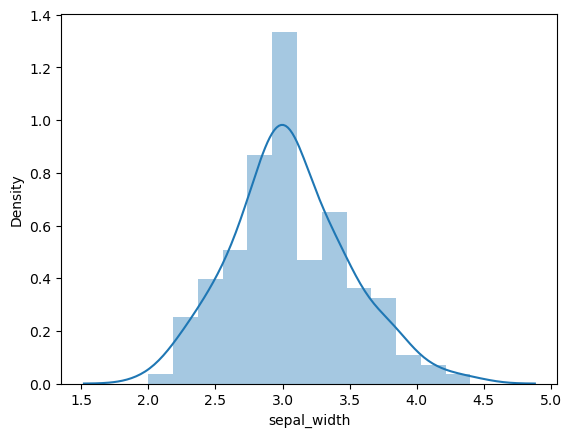

In [21]:
sns.distplot(df['sepal_width'])

In [22]:
df['sepal_width'].mean()

np.float64(3.0573333333333337)

In [23]:
df['sepal_width'].median()

3.0

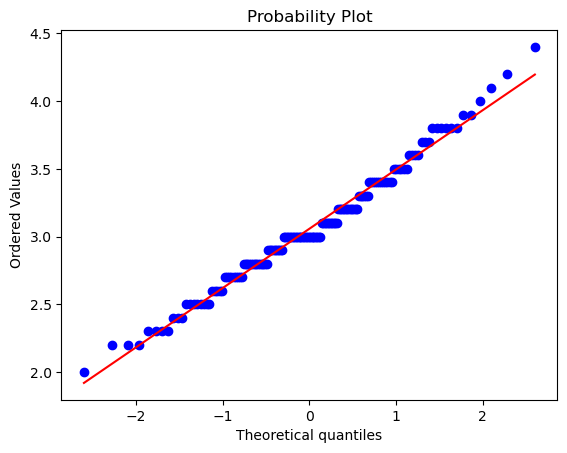

In [24]:
stats.probplot(df['sepal_width'],dist='norm',plot=plt)
plt.show()

In [25]:
TS,p_value=kstest(df['sepal_width'],'norm')
p_value

np.float64(1.9343513094431768e-253)

In [26]:
result=anderson(df['sepal_width'])
result

AndersonResult(statistic=np.float64(0.9079550471145126), critical_values=array([0.562, 0.64 , 0.767, 0.895, 1.065]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(3.0573333333333337), scale=np.float64(0.435866284936698))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

In [27]:
def CDF(data):
    sort_data=np.sort(data)
    cdf_values=np.arange(1,len(sort_data)+1)/len(sort_data)
    return sort_data,cdf_values

In [28]:
data=df['sepal_width']
sort,cdf=CDF(data)

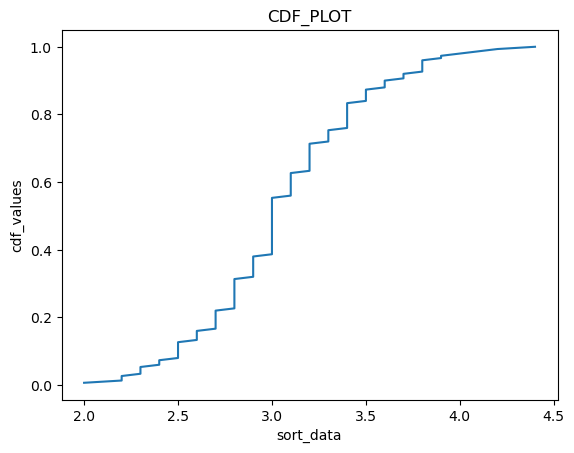

In [29]:
plt.plot(sort,cdf)
plt.title('CDF_PLOT')
plt.xlabel('sort_data')
plt.ylabel('cdf_values')
plt.show()
# with help of cdf i am telling that 80% of data <=6.5


In [30]:
norm.cdf(3.5,np.mean(df['sepal_width']),np.std(df['sepal_width']))

np.float64(0.845899549778257)

<Axes: xlabel='sepal_length', ylabel='Count'>

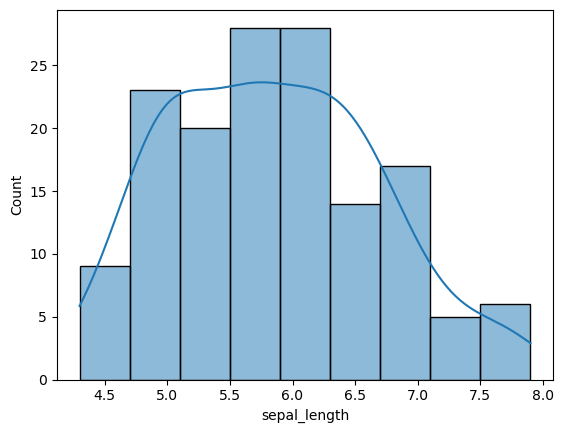

In [31]:
sns.histplot(df['sepal_length'],kde=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12888\2820515964.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['petal_length'])


<Axes: xlabel='petal_length', ylabel='Density'>

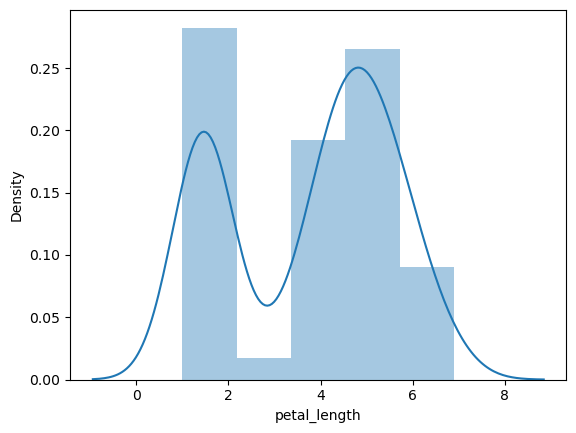

In [32]:
#CHECK NEW COLUMN 
sns.distplot(df['petal_length'])

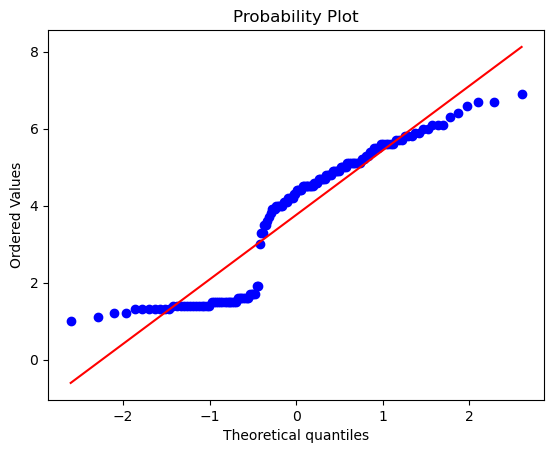

In [33]:
#check QQ plot
stats.probplot(df['petal_length'],dist='norm',plot=plt)
plt.show()

In [34]:
#ks test
TS,p_value=kstest(df['petal_length'],'norm')
p_value
#it is not following Gaussain

np.float64(1.4044248603466367e-136)

In [35]:
1.4044248603466367e-136>0.05

False

In [36]:
#ANDERSON
TS,critical_values,s_level=anderson(df['petal_length'])
TS>critical_values[2]
#test_statastics is > 5% significant level hence H0 rejected

np.True_

In [37]:
#Shapiro wilk
from scipy.stats import shapiro
TS,p_value=shapiro(df['sepal_width'])
if p_value>0.05:
    print('Fail to reject H0,given data is following Gaussian distribution')
else:
    print('H0 is rejected given data is not following Gaussian distribution')

Fail to reject H0,given data is following Gaussian distribution


<Axes: xlabel='sepal_width', ylabel='Count'>

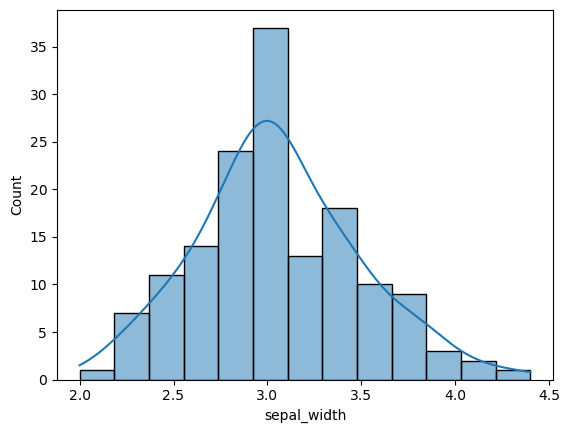

In [38]:
sns.histplot(df['sepal_width'],kde=True)
#this data follows gaussian distribution

In [39]:
#CDF 
def cdf(data):
    sort_data=np.sort(data)
    cdf=np.arange(1,len(sort_data)+1)/len(sort_data)
    return sort_data,cdf
data=df['sepal_width']
sort_data,cdf=cdf(data)

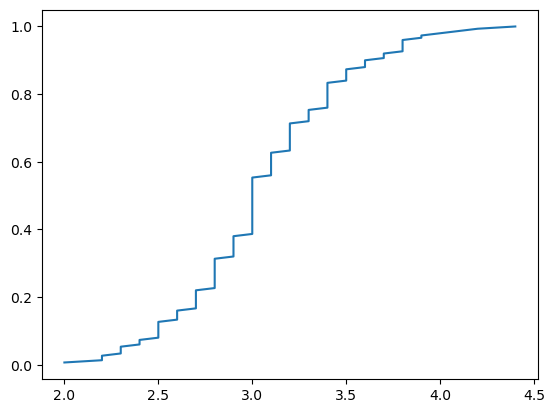

In [40]:
plt.plot(sort_data,cdf)
plt.show()

In [41]:
# Emphirical Bootstaping
def bootstrap(data,sample_size,no_of_samples):
    boot_data=[]
    for i in range(no_of_samples):
        get_data=np.random.choice(data,sample_size)
        boot_data.append(np.median(get_data))
    return boot_data
data=df['sepal_width']
sample_size=30
no_of_samples=1000
boot=bootstrap(data,sample_size,no_of_samples)

In [42]:
lower_limit=np.percentile(boot,2.5)
upper_limit=np.percentile(boot,97.5)

In [43]:
lower_limit,upper_limit
#i am 95% percent confident the popuation median is graterthan 3.2 and lessthan 2.9

(np.float64(2.9), np.float64(3.2))

# Bivariate Analysis

Text(0, 0.5, 'sepal_width')

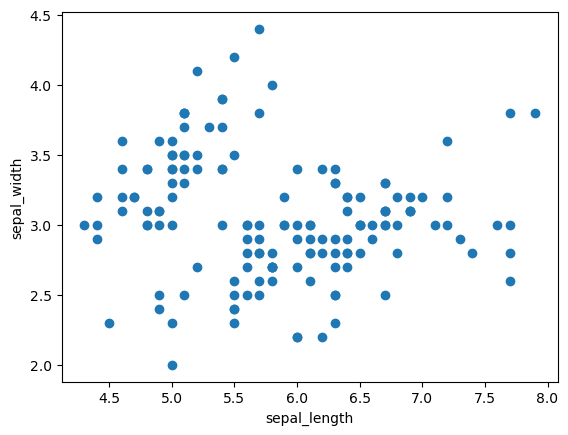

In [45]:
plt.scatter(df['sepal_length'],df['sepal_width'])
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')

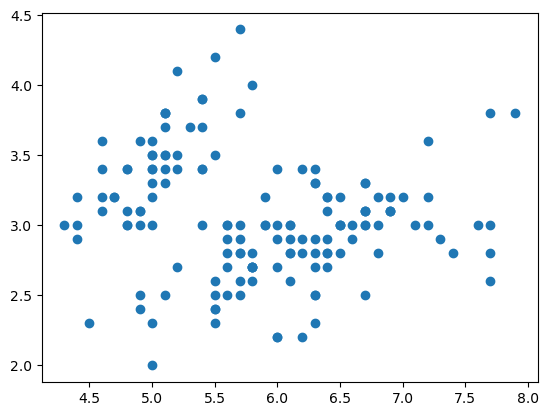

np.float64(-0.11756978413300208)

In [8]:
plt.scatter(x='sepal_length',y='sepal_width',data=df)
plt.show()
df['sepal_length'].corr(df['sepal_width'])

In [46]:
#their is  no linear relationship between sepal length and sepal width
#sepal_length is varies from 4.2 to 7.9
#sepal_width is varries from 2 to 4.4

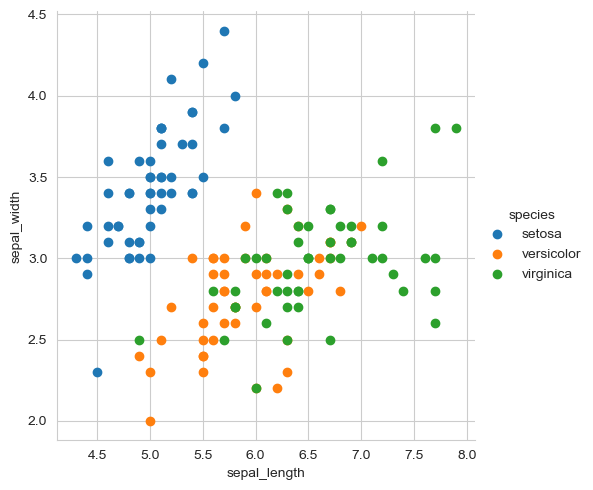

In [52]:
sns.set_style('whitegrid')
sns.FacetGrid(df,hue="species",height=5).map(plt.scatter,'sepal_length','sepal_width').add_legend();
plt.show()

In [53]:
#BY seeing this dig setosa  is looking like somewhat separable
#versicolor and virginica points are overlapping

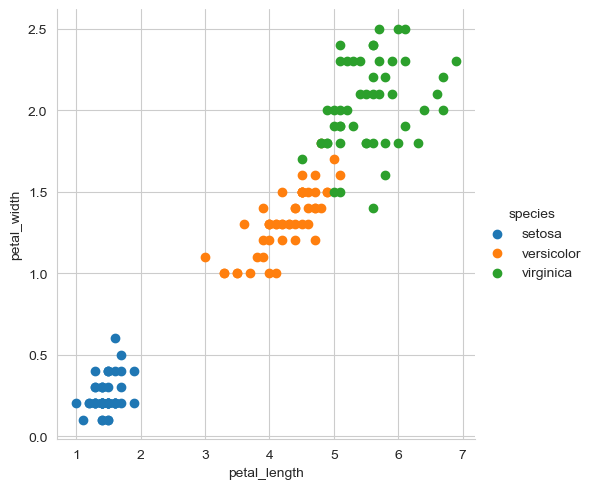

In [54]:
sns.set_style('whitegrid')
sns.FacetGrid(df,hue="species",height=5).map(plt.scatter,'petal_length','petal_width').add_legend();
plt.show()

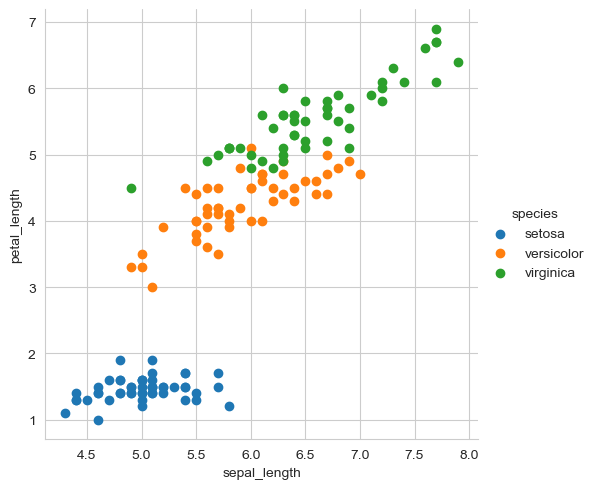

In [55]:
sns.set_style('whitegrid')
sns.FacetGrid(df,hue="species",height=5).map(plt.scatter,'sepal_length','petal_length').add_legend();
plt.show()

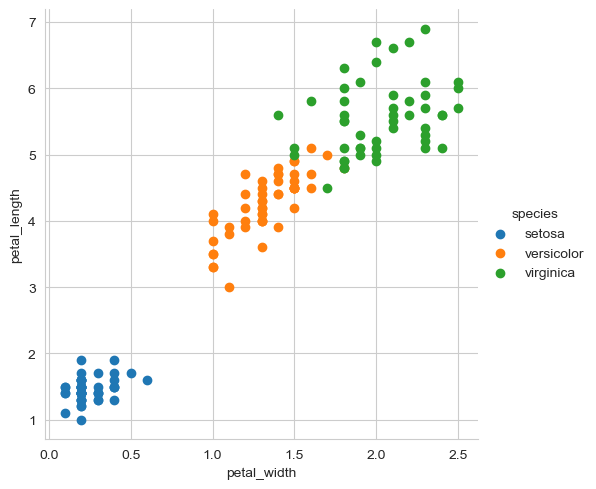

In [58]:
sns.set_style('whitegrid')
sns.FacetGrid(df,hue="species",height=5).map(plt.scatter,'petal_width','petal_length').add_legend();
plt.show()

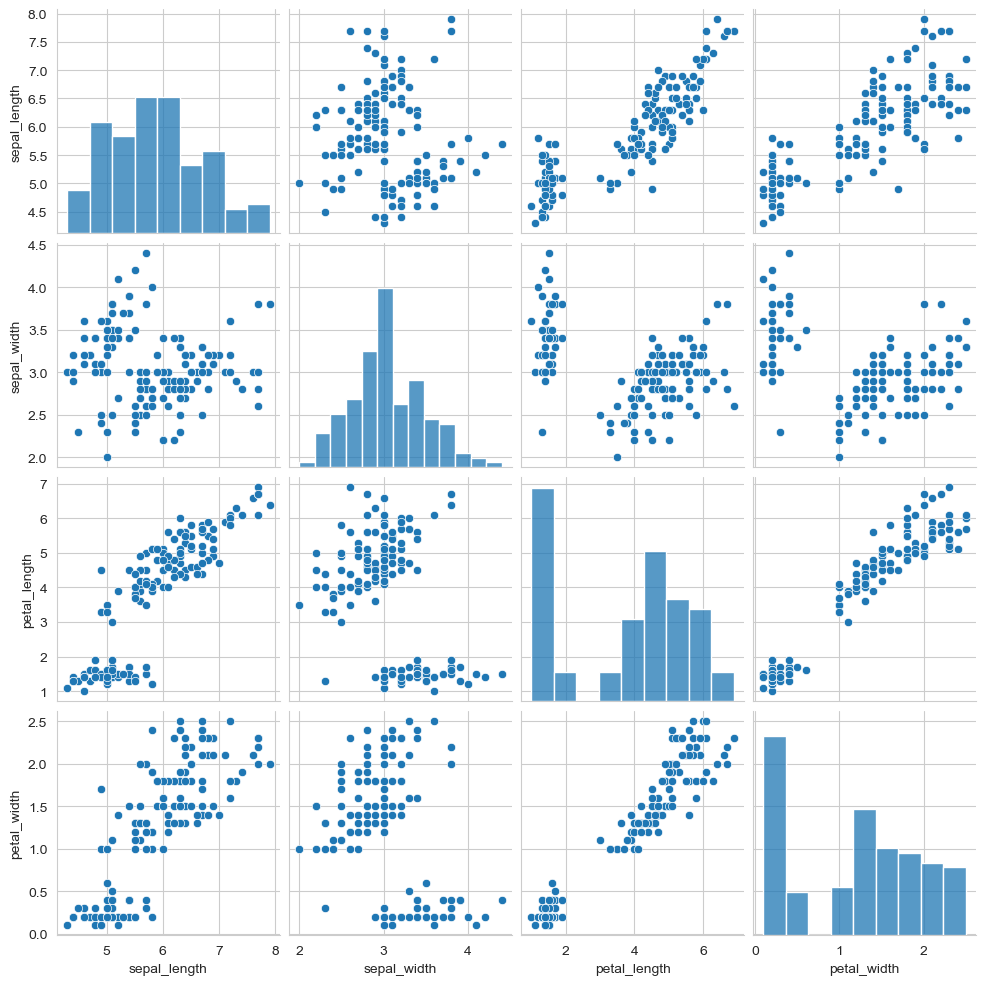

In [59]:
sns.pairplot(df)
plt.show()

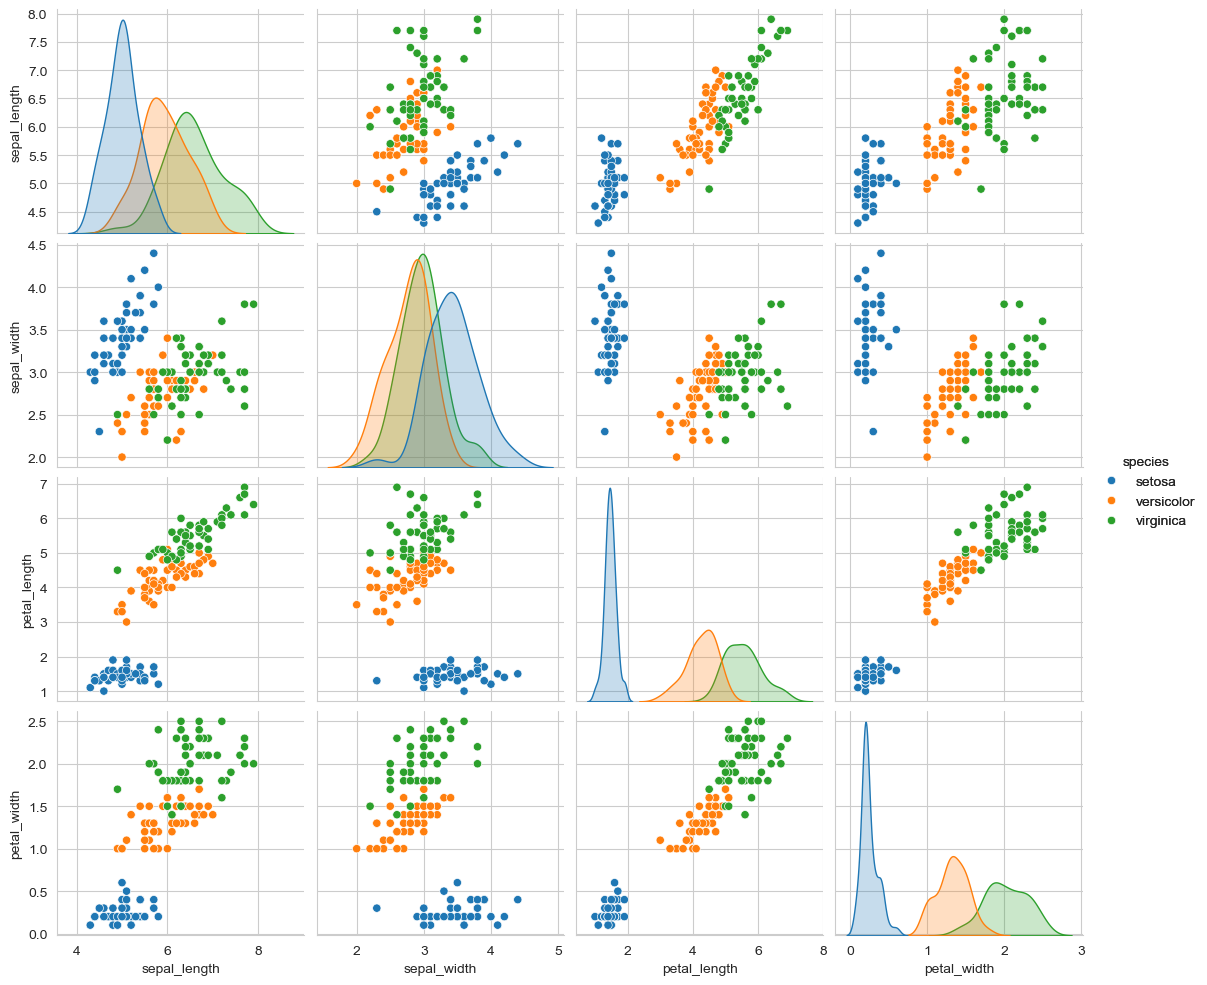

In [60]:
sns.pairplot(df,hue='species').add_legend()
plt.show()

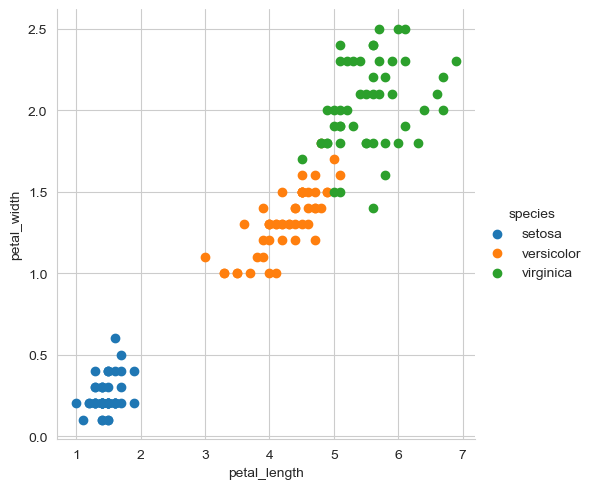

In [61]:
sns.set_style('whitegrid')
sns.FacetGrid(df,hue="species",height=5).map(plt.scatter,'petal_length','petal_width').add_legend();
plt.show()

In [62]:
#if (PL>=0.8 and PL<=1.9) and (PW>=0.2 and PW<=0.7)-->setosa
#if (PL>=3.0 and PL<=5.1) and (PW>=1.0 and PW<=1.4)-->versicolor
#if (PL>=4.5 and PL<=6.9) and (PW>=1.4 and PW<=2.5)-->versicolor

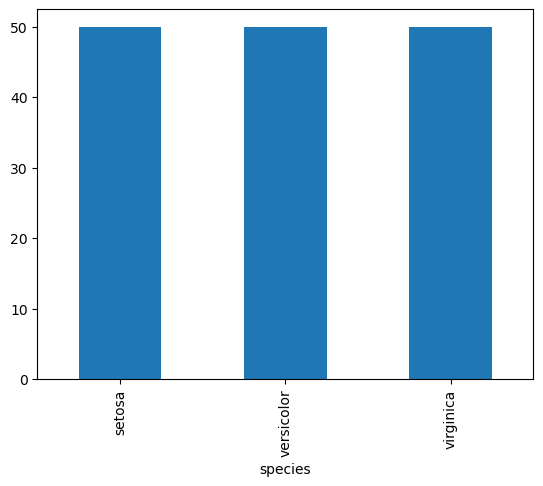

In [11]:
df['species'].value_counts().plot(kind='bar')
plt.show()


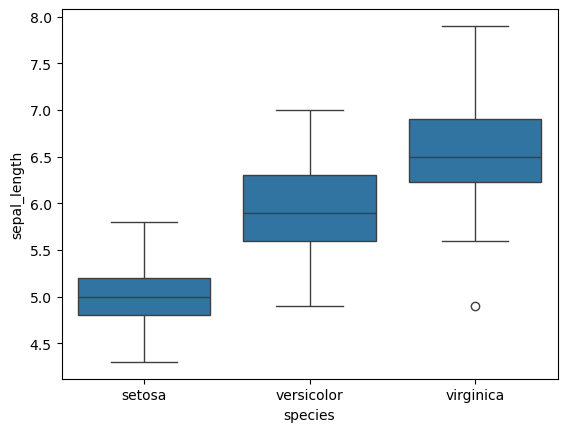

In [6]:
sns.boxplot(x='species',y='sepal_length',data=df)
plt.show()